# Principal Component Analysis

In [1]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Cancer_Data.csv')
data.drop(columns = data.columns[-1], inplace = True)

# The data is categorized into two categories: Malignant and Benign
# This is summarized in the table as "diagnosis" column

# The "diagnosis" column is thus the target
y = data["diagnosis"]
# characteristics -- everything other than id and diagnosis result
X = data.iloc[:,2:]

In [3]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR

In [4]:
#standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Some data are used as training data, while others are used as testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)   # 20% of the data is used for test, 80% used as training data
pca = PCA(n_components=1, copy = True)
pca.fit(X_train)
X_train_reduction = pca.transform(X_train)
X_test_reduction = pca.transform(X_test)


In [6]:
%%time
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)

CPU times: user 885 µs, sys: 76 µs, total: 961 µs
Wall time: 925 µs


KNeighborsClassifier()

In [7]:
knn_clf.score(X_test, y_test)

0.9649122807017544

In [8]:
%%time
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_reduction, y_train)

CPU times: user 3.14 ms, sys: 284 µs, total: 3.43 ms
Wall time: 724 µs


KNeighborsClassifier()

## Some better illustration of looking at graphs.

In [9]:
from sklearn.datasets import fetch_lfw_people


In [10]:
from pca import PCA

In [11]:
faces = fetch_lfw_people(min_faces_per_person=60)
faces.images.shape

(1348, 62, 47)

In [12]:
faces
# 

{'data': array([[0.53333336, 0.52418303, 0.49673203, ..., 0.00653595, 0.00653595,
         0.00130719],
        [0.28627452, 0.20784314, 0.2535948 , ..., 0.96993464, 0.95032686,
         0.9346406 ],
        [0.31633988, 0.3895425 , 0.275817  , ..., 0.4261438 , 0.7895425 ,
         0.9555555 ],
        ...,
        [0.11633987, 0.11111111, 0.10196079, ..., 0.5660131 , 0.579085  ,
         0.5542484 ],
        [0.19346406, 0.21045752, 0.29150328, ..., 0.6875817 , 0.6575164 ,
         0.5908497 ],
        [0.12418301, 0.09673203, 0.10849673, ..., 0.12941177, 0.16209151,
         0.29150328]], dtype=float32),
 'images': array([[[0.53333336, 0.52418303, 0.49673203, ..., 0.2653595 ,
          0.2653595 , 0.26013073],
         [0.56993467, 0.545098  , 0.4797386 , ..., 0.2627451 ,
          0.2627451 , 0.26013073],
         [0.5882353 , 0.5398693 , 0.475817  , ..., 0.2640523 ,
          0.26013073, 0.25751635],
         ...,
         [0.59738564, 0.7176471 , 0.40261438, ..., 0.00653595,
     

In [13]:
X = faces.data
X.shape
# in data (characteristic matrix), each row is a sample
# each column is all cahracteristics related to the sample

(1348, 2914)

In [14]:
# images are in 3D array
faces.images.shape
# 1348 is the number of images
# 62 is the number of rows of the characteristic matrix
# 47 is the number of columns of the characteristic matrix

(1348, 62, 47)

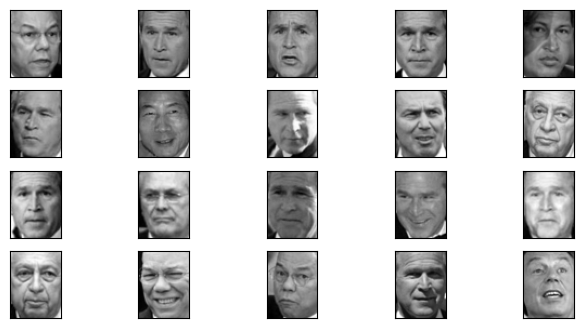

In [15]:
fig, axes = plt.subplots (4,5, figsize = (8,4), subplot_kw = {"xticks":[], "yticks":[]})


# fill in the graphs
for i, ax, in enumerate (axes.flat):
    ax.imshow(faces.images[i, :, :], cmap = 'gray')

In [16]:
pca = PCA(n_components=150).fit(X)
V = pca.components_
V.shape

(150, 2914)

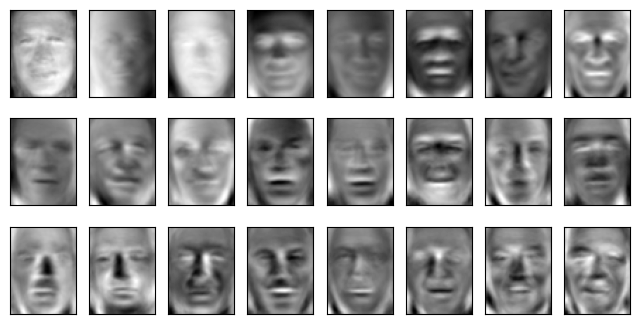

In [17]:
# visualize the new characteristic matrix
fig, axes = plt.subplots (3,8, figsize = (8,4), subplot_kw = {"xticks":[], "yticks":[]})


# fill in the graphs
for i, ax, in enumerate (axes.flat):
    ax.imshow(V[i, :].reshape(62,47), cmap = 'gray')

From the comparison of the graphs, it's clear that the highlights and the shadows of a human face is clear. Typical facial organs (such as eyes, nose, mouth) are relatively clear as well. Other features of the face are less clear. This shows that after PCA, the new characteristic matrix is likely about lightness and facial organs.